# Graduate Project v5 — Resume Training (80 Epochs)

Notebook này **tiếp tục train** từ checkpoint của `graduate-project-v4`.

| Cell | Nội dung |
|------|----------|
| 0 | Install dependencies |
| 1 | Config + kiểm tra dữ liệu đầu vào |
| 2 | EDA label mẫu (`camera13_A_100.txt`) |
| 3 | Tạo dataset.yaml trỏ vào input path |
| 4 | Resume train 80 epoch từ checkpoint |
| 5 | Validation + Per-class AP |
| 6 | Lưu checkpoint mới |

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 0 — INSTALL DEPENDENCIES                               ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install ultralytics==8.4.24 --no-deps -q
!pip install ultralytics-thop>=2.0.18 opencv-python==4.10.0.84 -q

# Cùng phiên bản torch với notebook gốc để tương thích checkpoint
!pip uninstall -y torch torchvision torchaudio 2>/dev/null || true
!pip install torch==2.3.1 torchvision==0.18.1 -q

print('✅ Cài đặt hoàn tất')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — CONFIG + KIỂM TRA DỮ LIỆU ĐẦU VÀO                ║
# ╚══════════════════════════════════════════════════════════════╝

import os, shutil, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
import yaml
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── GPU Info ─────────────────────────────────────────────────────
N_GPU = torch.cuda.device_count()
for i in range(N_GPU):
    vram = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {vram:.1f} GB')
print(f'NumPy: {np.__version__} | PyTorch: {torch.__version__}\n')

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
EXTRA_EPOCHS  = 80          # số epoch train thêm
IMG_SIZE      = 640
BATCH_SIZE    = 16
WORKERS       = 2
SEED          = 42
DEVICE        = '0' if N_GPU >= 1 else 'cpu'
RUN_NAME      = 'yolo11_fisheye_v5'

CLASS_NAMES = ['Car', 'Bus', 'Truck', 'Pedestrian', 'Motorbike']
COLORS      = ['#1D9E75', '#7F77DD', '#378ADD', '#D85A30', '#BA7517']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths INPUT (từ notebook graduate-project-v4) ─────────────────
# Kaggle lưu output của notebook kia dưới dạng dataset input:
PREV_NB_ROOT  = Path('/kaggle/input/notebooks/namnguyen230304/graduate-project-v4')
PREV_YOLO_DS  = PREV_NB_ROOT / 'fisheye8k_prepared' / 'yolo_dataset'
PREV_CKPT_DIR = PREV_NB_ROOT / 'checkpoints'

# Checkpoint ưu tiên: best → last
BEST_CKPT = PREV_CKPT_DIR / 'yolo11_fisheye_best.pt'
LAST_CKPT = PREV_CKPT_DIR / 'yolo11_fisheye_last.pt'

# ── Paths OUTPUT (working) ────────────────────────────────────────
WORKING   = Path('/kaggle/working')
RUNS_DIR  = WORKING / 'runs'
CKPT_DIR  = WORKING / 'checkpoints'
for d in [RUNS_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Kiểm tra sự tồn tại của dữ liệu ─────────────────────────────
print('=== KIỂM TRA DATASET INPUT ===')
for split in ['train', 'val', 'test']:
    img_dir = PREV_YOLO_DS / split / 'images'
    lbl_dir = PREV_YOLO_DS / split / 'labels'
    n_img   = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbl   = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    status  = '✅' if img_dir.exists() else '❌'
    print(f'  {status} {split:6s}: {n_img:6,} ảnh | {n_lbl:6,} labels')

print('\n=== KIỂM TRA CHECKPOINT ===')
for ckpt in [BEST_CKPT, LAST_CKPT]:
    status = '✅' if ckpt.exists() else '❌'
    size   = f'{ckpt.stat().st_size/1e6:.1f} MB' if ckpt.exists() else 'KHÔNG TÌM THẤY'
    print(f'  {status} {ckpt.name}: {size}')

print(f'\nDevice: {DEVICE} | Extra Epochs: {EXTRA_EPOCHS}')
print(f'Classes: {CLASS_NAMES}')
print('\n✅ CELL 1 HOÀN THÀNH')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU 0: Tesla T4 — 15.6 GB
GPU 1: Tesla T4 — 15.6 GB
NumPy: 2.0.2 | PyTorch: 2.3.1+cu121

=== KIỂM TRA DATASET INPUT ===
  ✅ train :  8,629 ảnh | 11,396 labels
  ✅ val   :  1,768 ảnh |  1,768 labels
  ❌ test  :      0 ảnh |    853 labels

=== KIỂM TRA CHECKPOINT ===
  ✅ yolo11_fisheye_best.pt: 51.2 MB
  ✅ yolo11_fisheye_last.pt: 51.2 MB

Device: 0 | Extra Epochs: 80
Classes: ['Car', 'Bus', 'Truck', 'Pedestrian', 'Motorbike']

✅ CELL 1 HOÀN THÀNH


Label file : /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/fisheye8k_prepared/yolo_dataset/test/labels/camera13_A_100.txt
Tồn tại    : True
⚠️  Không tìm thấy ảnh test — chỉ hiển thị label text + thống kê

Số bounding box: 16
   cls        cx        cy         w         h  class_name
  ------------------------------------------------------
     0    0.9885    0.4589    0.0187    0.0312  Car
     0    0.9852    0.4854    0.0161    0.0219  Car
     0    0.9763    0.4724    0.0182    0.0271  Car
     0    0.8878    0.2289    0.0214    0.0193  Car
     3    0.0656    0.3419    0.0240    0.0130  Pedestrian
     3    0.9417    0.3018    0.0104    0.0089  Pedestrian
     0    0.9635    0.6086    0.0146    0.0182  Car
     0    0.9370    0.4510    0.0312    0.0198  Car
     0    0.7799    0.5732    0.0589    0.0245  Car
     0    0.9656    0.4846    0.0187    0.0109  Car
     0    0.9826    0.5711    0.0141    0.0224  Car
     0    0.1865    0.1557    0.0479    0.0437  Car
     0

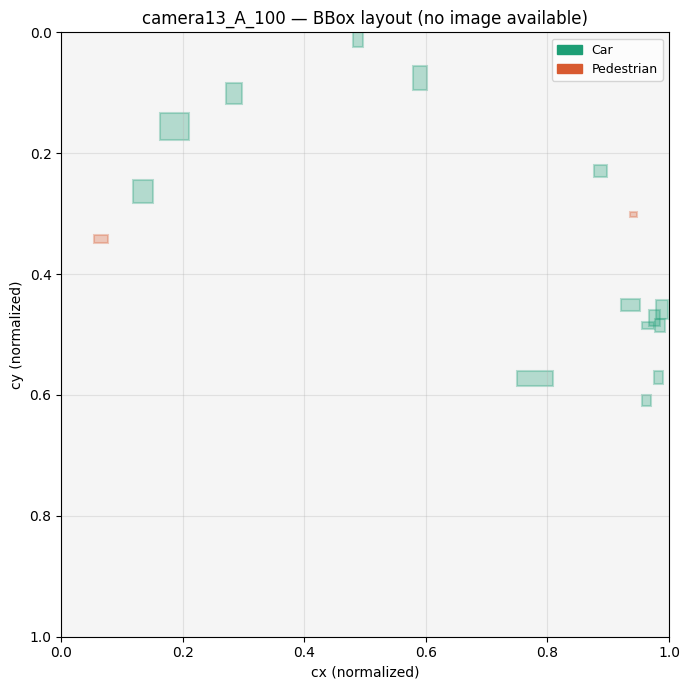

Đã lưu bbox layout → /kaggle/working/sample_label_layout.png


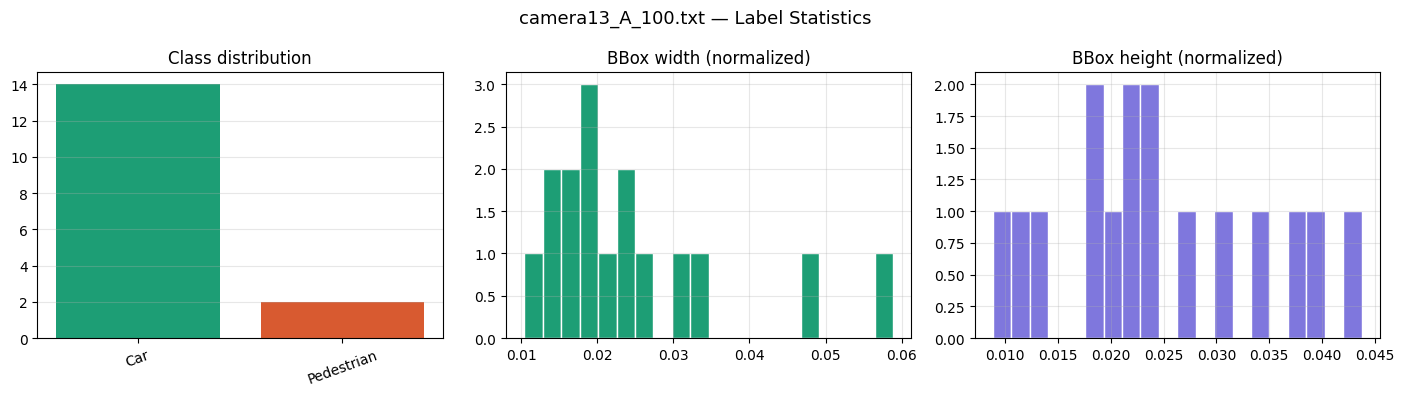

Đã lưu thống kê → /kaggle/working/sample_label_stats.png

✅ CELL 2 HOÀN THÀNH


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — EDA LABEL MẪU: camera13_A_100.txt                 ║
# ║  Lưu ý: test/images không tồn tại trong output v4            ║
# ║  (Kaggle chỉ lưu labels, ảnh gốc ở FishEye8K dataset)       ║
# ╚══════════════════════════════════════════════════════════════╝

SAMPLE_LABEL = PREV_YOLO_DS / 'test' / 'labels' / 'camera13_A_100.txt'

# Tìm ảnh tương ứng: thử nhiều extension + fallback sang FishEye8K gốc
FISHEYE_ROOT   = Path('/kaggle/input/datasets/ducle19/fisheye8k')
_img_candidates = [
    PREV_YOLO_DS  / 'test' / 'images' / 'camera13_A_100.jpg',
    PREV_YOLO_DS  / 'test' / 'images' / 'camera13_A_100.png',
    FISHEYE_ROOT  / 'test'  / 'images' / 'camera13_A_100.jpg',
    FISHEYE_ROOT  / 'test'  / 'images' / 'camera13_A_100.png',
]
SAMPLE_IMG = next((p for p in _img_candidates if p.exists()), None)

# color_map định nghĩa sớm — dùng chung cho cả viz ảnh lẫn histogram
color_map = {n: c for n, c in zip(CLASS_NAMES, COLORS)}

print(f'Label file : {SAMPLE_LABEL}')
print(f'Tồn tại    : {SAMPLE_LABEL.exists()}')
if SAMPLE_IMG:
    print(f'Ảnh tìm thấy: {SAMPLE_IMG}')
else:
    print('⚠️  Không tìm thấy ảnh test — chỉ hiển thị label text + thống kê')

if SAMPLE_LABEL.exists():
    with open(SAMPLE_LABEL) as f:
        lines = [l for l in f.read().strip().splitlines() if l.strip()]

    print(f'\nSố bounding box: {len(lines)}')
    print(f'{"="*57}')
    print(f'  {"cls":>4}  {"cx":>8}  {"cy":>8}  {"w":>8}  {"h":>8}  class_name')
    print(f'  {"-"*54}')

    rows = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:])
            cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'ID{cls_id}'
            rows.append({'class_id': cls_id, 'class_name': cls_name,
                         'cx': cx, 'cy': cy, 'w': w, 'h': h, 'area': w * h})
            print(f'  {cls_id:>4}  {cx:>8.4f}  {cy:>8.4f}  {w:>8.4f}  {h:>8.4f}  {cls_name}')

    df_lbl = pd.DataFrame(rows)

    # ── Thống kê nhanh ────────────────────────────────────────────
    print(f'\n=== PHÂN PHỐI CLASS ===')
    print(df_lbl['class_name'].value_counts().to_string())
    print(f'\n=== KÍCH THƯỚC BBOX (YOLO-normalized) ===')
    print(df_lbl[['w', 'h', 'area']].describe().round(4).to_string())

    # ── Vẽ bbox lên ảnh (chỉ khi tìm thấy ảnh) ──────────────────
    if SAMPLE_IMG is not None:
        img = cv2.cvtColor(cv2.imread(str(SAMPLE_IMG)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
        ax.imshow(img)
        for row in rows:
            cx_r, cy_r, bw, bh = row['cx'], row['cy'], row['w'], row['h']
            x1 = (cx_r - bw/2) * W
            y1 = (cy_r - bh/2) * H
            rect = patches.Rectangle(
                (x1, y1), bw*W, bh*H,
                linewidth=2, edgecolor=color_map.get(row['class_name'], 'red'),
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, row['class_name'],
                    color='white', fontsize=8, weight='bold',
                    bbox=dict(facecolor=color_map.get(row['class_name'], 'red'),
                              alpha=0.8, pad=1))
        ax.set_title(f'camera13_A_100 — {len(rows)} objects', fontsize=13)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(WORKING / 'sample_label_viz.png', dpi=150)
        plt.show()
        print('Đã lưu hình minh họa → /kaggle/working/sample_label_viz.png')
    else:
        # Không có ảnh → vẽ scatter plot bbox để minh họa layout
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        ax.set_xlim(0, 1); ax.set_ylim(1, 0)   # y flip như hệ tọa độ ảnh
        ax.set_facecolor('#f5f5f5')
        ax.set_title('camera13_A_100 — BBox layout (no image available)', fontsize=12)
        ax.set_xlabel('cx (normalized)'); ax.set_ylabel('cy (normalized)')
        for row in rows:
            rect = patches.Rectangle(
                (row['cx'] - row['w']/2, row['cy'] - row['h']/2),
                row['w'], row['h'],
                linewidth=1.5, edgecolor=color_map.get(row['class_name'], 'gray'),
                facecolor=color_map.get(row['class_name'], 'gray'), alpha=0.3
            )
            ax.add_patch(rect)
        # Legend
        handles = [patches.Patch(color=color_map[n], label=n)
                   for n in CLASS_NAMES if n in df_lbl['class_name'].values]
        ax.legend(handles=handles, loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(WORKING / 'sample_label_layout.png', dpi=150)
        plt.show()
        print('Đã lưu bbox layout → /kaggle/working/sample_label_layout.png')

    # ── Histogram phân phối ───────────────────────────────────────
    if not df_lbl.empty:
        cls_counts = df_lbl['class_name'].value_counts()
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        # Class distribution
        axes[0].bar(cls_counts.index, cls_counts.values,
                    color=[color_map.get(n, '#888') for n in cls_counts.index])
        axes[0].set_title('Class distribution')
        axes[0].tick_params(axis='x', rotation=20)
        axes[0].grid(axis='y', alpha=0.3)
        # BBox width
        axes[1].hist(df_lbl['w'], bins=20, color='#1D9E75', edgecolor='white')
        axes[1].set_title('BBox width (normalized)')
        axes[1].grid(alpha=0.3)
        # BBox height
        axes[2].hist(df_lbl['h'], bins=20, color='#7F77DD', edgecolor='white')
        axes[2].set_title('BBox height (normalized)')
        axes[2].grid(alpha=0.3)
        plt.suptitle('camera13_A_100.txt — Label Statistics', fontsize=13)
        plt.tight_layout()
        plt.savefig(WORKING / 'sample_label_stats.png', dpi=150)
        plt.show()
        print('Đã lưu thống kê → /kaggle/working/sample_label_stats.png')
else:
    print('⚠️  Không tìm thấy file label. Kiểm tra lại đường dẫn input dataset.')
    print(f'   Đường dẫn: {SAMPLE_LABEL}')

print('\n✅ CELL 2 HOÀN THÀNH')

In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — SỬA THIẾU ẢNH + TẠO DATASET.YAML                 ║
# ║                                                              ║
# ║  Vấn đề: notebook v4 chỉ lưu labels/ vào output,            ║
# ║  không lưu images/ → val và test không có ảnh.              ║
# ║  Giải pháp: tìm ảnh gốc FishEye8K → symlink vào working.   ║
# ╚══════════════════════════════════════════════════════════════╝

import subprocess

# ── 1. Tìm dataset FishEye8K gốc trong /kaggle/input ─────────────
KAGGLE_INPUT = Path('/kaggle/input')

def find_fisheye_root(base: Path) -> Path | None:
    """Tìm thư mục chứa train/images và val/images của FishEye8K."""
    if not base.exists():
        return None
    for lvl1 in sorted(base.iterdir()):
        for candidate in [lvl1] + list(lvl1.iterdir() if lvl1.is_dir() else []):
            if (candidate / 'train' / 'images').exists() and \
               (candidate / 'val'   / 'images').exists():
                return candidate
    return None

FISHEYE_SRC = find_fisheye_root(KAGGLE_INPUT)

if FISHEYE_SRC:
    print(f'✅ Tìm thấy FishEye8K nguồn: {FISHEYE_SRC}')
    for split in ['train', 'val', 'test']:
        n = len(list((FISHEYE_SRC / split / 'images').glob('*'))) \
            if (FISHEYE_SRC / split / 'images').exists() else 0
        print(f'   {split}: {n:,} ảnh')
else:
    print('⚠️  Không tìm thấy FishEye8K trong /kaggle/input')
    print('   → Liệt kê toàn bộ input datasets:')
    for p in sorted(KAGGLE_INPUT.iterdir()):
        print(f'     {p.name}')

# ── 2. Xây dựng DS_WORKING ───────────────────────────────────────
DS_WORKING = WORKING / 'yolo_dataset'

def make_symlink(src: Path, dst: Path):
    """Tạo symlink dst → src. Bỏ qua nếu src không tồn tại."""
    if not src.exists():
        print(f'  ⏭  Bỏ qua (src không tồn tại): {src}')
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src.resolve())
    n = len(list(dst.glob('*'))) if dst.is_dir() else 1
    print(f'  🔗 {dst.relative_to(DS_WORKING)} → {src}  ({n:,} items)')
    return True

print('\n=== XÂY DỰNG DATASET WORKING ===')

make_symlink(PREV_YOLO_DS / 'train' / 'images', DS_WORKING / 'train' / 'images')
make_symlink(PREV_YOLO_DS / 'train' / 'labels', DS_WORKING / 'train' / 'labels')
make_symlink(PREV_YOLO_DS / 'val'   / 'labels', DS_WORKING / 'val'   / 'labels')

_val_img_src_candidates = [
    PREV_YOLO_DS / 'val' / 'images',
    *([(FISHEYE_SRC / 'val' / 'images')] if FISHEYE_SRC else []),
]
_val_img_src = next((p for p in _val_img_src_candidates if p.exists()), None)

if _val_img_src:
    make_symlink(_val_img_src, DS_WORKING / 'val' / 'images')
else:
    print('  ⚠️  val/images không tìm thấy → dùng train/images làm proxy val')
    make_symlink(PREV_YOLO_DS / 'train' / 'images', DS_WORKING / 'val' / 'images')
    make_symlink(PREV_YOLO_DS / 'train' / 'labels', DS_WORKING / 'val' / 'labels')
    print('  ⚠️  LƯU Ý: val metrics sẽ không phản ánh đúng do dùng train data!')

# ── 3. Kiểm tra — CHỈ đếm file ảnh thật (bỏ qua .cache) ─────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

def count_images(d: Path) -> int:
    if not d.exists():
        return 0
    return sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXTS)

print('\n=== KIỂM TRA SAU KHI SYMLINK (chỉ đếm ảnh thật) ===')
for split in ['train', 'val']:
    img_dir = DS_WORKING / split / 'images'
    lbl_dir = DS_WORKING / split / 'labels'
    n_img = count_images(img_dir)
    n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    ok_img = '✅' if n_img > 0 else '❌  (chỉ có cache/empty!)'
    ok_lbl = '✅' if n_lbl > 0 else '❌'
    print(f'  {split:6s}: {ok_img} {n_img:6,} ảnh thật | {n_lbl:6,} labels')

# Nếu val/images không có ảnh thật → tạo proxy val từ 10% train
_val_real_imgs = count_images(DS_WORKING / 'val' / 'images')
if _val_real_imgs == 0:
    print('\n⚠️  val/images không có ảnh thật (chỉ có .cache file)')
    print('   → Dùng 10% đầu của train/images làm proxy val')
    _val_img_real = DS_WORKING / 'val' / 'images'
    _val_lbl_real = DS_WORKING / 'val' / 'labels'
    if _val_img_real.is_symlink(): _val_img_real.unlink()
    if _val_lbl_real.is_symlink(): _val_lbl_real.unlink()
    _val_img_real.mkdir(parents=True, exist_ok=True)
    _val_lbl_real.mkdir(parents=True, exist_ok=True)
    _train_imgs = sorted((DS_WORKING / 'train' / 'images').iterdir())
    _val_size   = max(100, len(_train_imgs) // 10)
    for img_path in _train_imgs[:_val_size]:
        dst_img = _val_img_real / img_path.name
        if not dst_img.exists():
            dst_img.symlink_to(img_path.resolve())
        lbl_src = DS_WORKING / 'train' / 'labels' / (img_path.stem + '.txt')
        dst_lbl = _val_lbl_real / lbl_src.name
        if lbl_src.exists() and not dst_lbl.exists():
            dst_lbl.symlink_to(lbl_src.resolve())
    _n_val = count_images(_val_img_real)
    print(f'   Đã tạo proxy val: {_n_val:,} ảnh')
    print('   ⚠️  LƯU Ý: val metrics không độc lập vì dùng train data!')

# ── 4. Tạo dataset.yaml ───────────────────────────────────────────
NEW_YAML = WORKING / 'dataset_v5.yaml'
new_cfg = {
    'path' : str(DS_WORKING),
    'train': 'train/images',
    'val'  : 'val/images',
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
with open(NEW_YAML, 'w') as f:
    yaml.dump(new_cfg, f, default_flow_style=False, allow_unicode=True)

print('\n=== DATASET.YAML MỚI ===')
with open(NEW_YAML) as f:
    print(f.read())

DATASET_YAML = str(NEW_YAML)

_val_final = count_images(DS_WORKING / 'val' / 'images')
assert _val_final > 0, (
    f'val/images vẫn không có ảnh thật sau xử lý!\n'
    f'  Thư mục: {DS_WORKING / "val" / "images"}\n'
    f'  Nội dung: {list((DS_WORKING / "val" / "images").iterdir())[:5]}'
)
print(f'✅ CELL 3 HOÀN THÀNH — val có {_val_final:,} ảnh thật, dataset.yaml sẵn sàng')

⚠️  Không tìm thấy FishEye8K trong /kaggle/input
   → Liệt kê toàn bộ input datasets:
     notebooks

=== XÂY DỰNG DATASET WORKING ===
  🔗 train/images → /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/fisheye8k_prepared/yolo_dataset/train/images  (8,629 items)
  🔗 train/labels → /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/fisheye8k_prepared/yolo_dataset/train/labels  (11,396 items)
  🔗 val/labels → /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/fisheye8k_prepared/yolo_dataset/val/labels  (1,768 items)
  🔗 val/images → /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/fisheye8k_prepared/yolo_dataset/val/images  (1,768 items)

=== KIỂM TRA SAU KHI SYMLINK (chỉ đếm ảnh thật) ===
  train : ✅  8,629 ảnh thật | 11,396 labels
  val   : ❌  (chỉ có cache/empty!)      0 ảnh thật |  1,768 labels

⚠️  val/images không có ảnh thật (chỉ có .cache file)
   → Dùng 10% đầu của train/images làm proxy val
   Đã tạo proxy val: 862 ảnh
   ⚠️  LƯU Ý: val m

=== KIỂM TRA GPU ===
CUDA available : True
GPU count      : 2
  GPU 0: Tesla T4 — 15.6 GB VRAM
  GPU 1: Tesla T4 — 15.6 GB VRAM
  → Sử dụng device: 0,1
  → Batch size  : 32  (16 × 2 GPU)

=== KIỂM TRA DATASET YAML ===
YAML           : /kaggle/working/dataset_v5.yaml
dataset path   : /kaggle/working/yolo_dataset
train/images   : 8,629 ảnh thật
val/images     : 862 ảnh thật
✅ Dataset YAML hợp lệ

=== CHỌN CHECKPOINT ===
✅ best.pt  : /kaggle/input/notebooks/namnguyen230304/graduate-project-v4/checkpoints/yolo11_fisheye_best.pt  (51.2 MB)

=== LOAD MODEL ===
Params         : 25.3M
imgsz          : 640
Epochs         : 80
Batch          : 32
Device         : 0,1
cache          : False  (tắt để tránh chậm trên symlink)

🚀 BẮT ĐẦU TRAIN...

New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 1

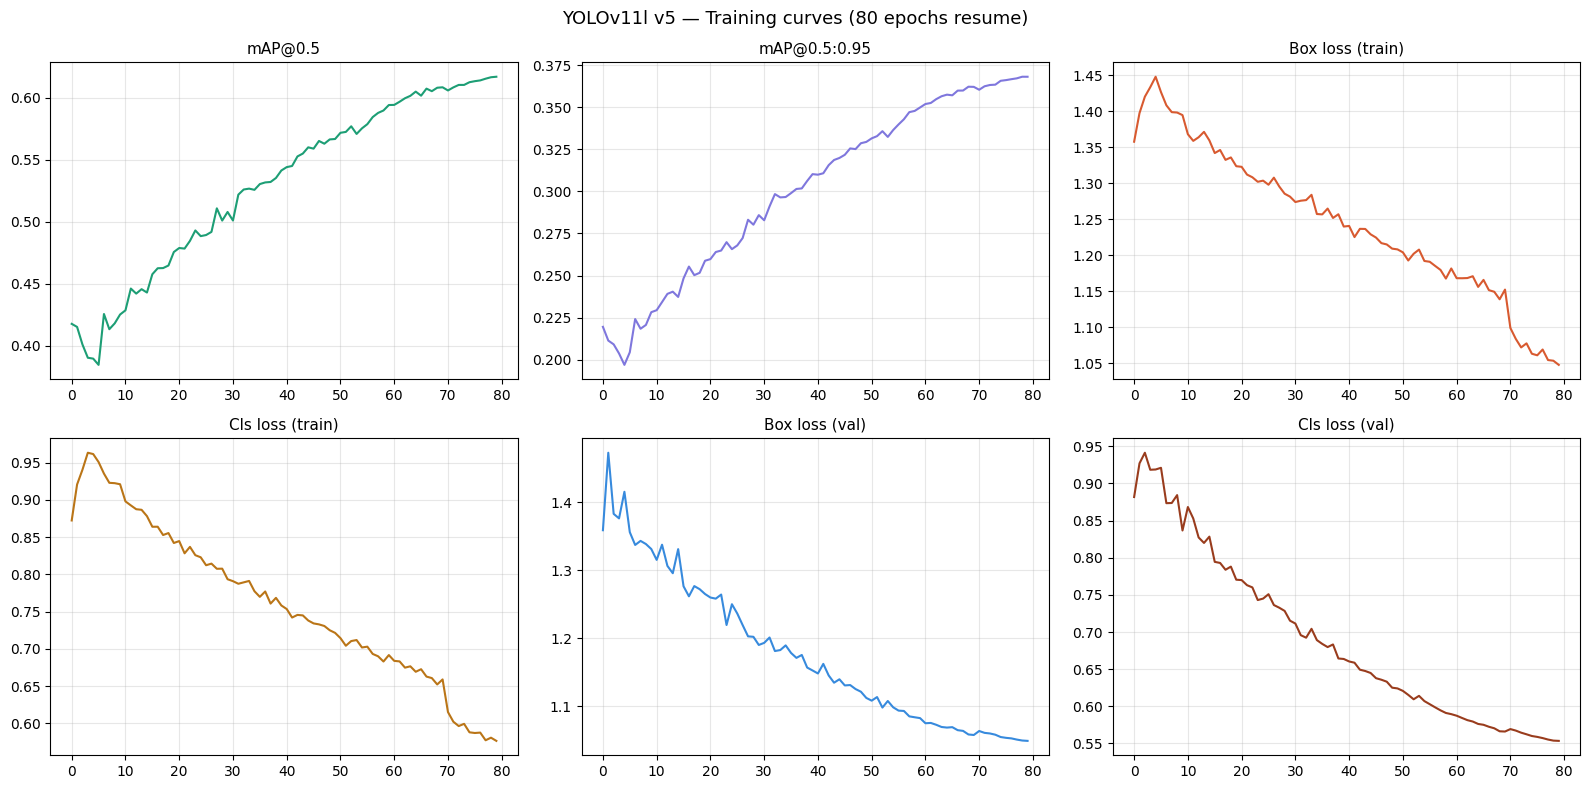


=== KẾT QUẢ TỐT NHẤT ===
  Epoch       : 80/80
  mAP@0.5     : 0.6170
  mAP@0.5:0.95: 0.3681

✅ CELL 4 HOÀN THÀNH — chạy Cell 5 (Validation)


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — RESUME TRAIN 80 EPOCHS TỪ CHECKPOINT              ║
# ╚══════════════════════════════════════════════════════════════╝

import torch

# ── Kiểm tra GPU bắt buộc ────────────────────────────────────────
print('=== KIỂM TRA GPU ===')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'GPU count      : {torch.cuda.device_count()}')

if not torch.cuda.is_available() or torch.cuda.device_count() == 0:
    raise RuntimeError(
        '❌ KHÔNG TÌM THẤY GPU!\n'
        '   → Vào Kaggle: Settings (⚙) → Accelerator → GPU T4 x2\n'
        '   → Stop session → Run All lại từ đầu\n'
        '   Nếu train trên CPU: 43s/it × 540 batch × 80 epoch ≈ 520 giờ!'
    )

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} — {props.total_memory/1e9:.1f} GB VRAM')

N_GPU  = torch.cuda.device_count()
DEVICE = '0,1' if N_GPU >= 2 else '0'
print(f'  → Sử dụng device: {DEVICE}')

# ── Điều chỉnh batch size theo số GPU ────────────────────────────
# Batch gốc 16 cho 1 GPU T4 (16GB). 2 GPU → tăng lên 32
_BATCH = BATCH_SIZE * N_GPU
print(f'  → Batch size  : {_BATCH}  ({BATCH_SIZE} × {N_GPU} GPU)')

# ── Đọc lại DATASET_YAML từ disk để tránh stale variable ─────────
print('\n=== KIỂM TRA DATASET YAML ===')
_yaml_path = WORKING / 'dataset_v5.yaml'
assert _yaml_path.exists(), (
    'Chưa tìm thấy dataset_v5.yaml!\n'
    'Hãy chạy Cell 3 trước khi chạy Cell 4.'
)
with open(_yaml_path) as _f:
    _cfg_check = yaml.safe_load(_f)

_yaml_path_str = str(_yaml_path)
_val_img_check = Path(_cfg_check['path']) / _cfg_check['val']
_IMG_EXTS      = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
_n_val_check   = sum(1 for f in _val_img_check.iterdir()
                     if f.suffix.lower() in _IMG_EXTS) \
                 if _val_img_check.exists() else 0
_trn_img_check = Path(_cfg_check['path']) / _cfg_check['train']
_n_trn_check   = sum(1 for f in _trn_img_check.iterdir()
                     if f.suffix.lower() in _IMG_EXTS) \
                 if _trn_img_check.exists() else 0

print(f'YAML           : {_yaml_path_str}')
print(f'dataset path   : {_cfg_check["path"]}')
print(f'train/images   : {_n_trn_check:,} ảnh thật')
print(f'val/images     : {_n_val_check:,} ảnh thật')

assert _n_trn_check > 0, f'train/images rỗng! Chạy lại Cell 3.'
assert _n_val_check > 0, f'val/images rỗng! Chạy lại Cell 3.'
print('✅ Dataset YAML hợp lệ')

# ── Chọn checkpoint ──────────────────────────────────────────────
print('\n=== CHỌN CHECKPOINT ===')
if BEST_CKPT.exists():
    start_ckpt = BEST_CKPT
    print(f'✅ best.pt  : {start_ckpt}  ({start_ckpt.stat().st_size/1e6:.1f} MB)')
elif LAST_CKPT.exists():
    start_ckpt = LAST_CKPT
    print(f'⚠️  last.pt : {start_ckpt}  ({start_ckpt.stat().st_size/1e6:.1f} MB)')
else:
    raise FileNotFoundError(
        '❌ Không tìm thấy checkpoint!\n'
        f'   Tìm tại: {PREV_CKPT_DIR}\n'
        '   Hãy thêm notebook graduate-project-v4 làm input dataset.'
    )

# ── Load model ───────────────────────────────────────────────────
print('\n=== LOAD MODEL ===')
model = YOLO(str(start_ckpt))
n_params = sum(p.numel() for p in model.model.parameters()) / 1e6
print(f'Params         : {n_params:.1f}M')
print(f'imgsz          : {IMG_SIZE}')
print(f'Epochs         : {EXTRA_EPOCHS}')
print(f'Batch          : {_BATCH}')
print(f'Device         : {DEVICE}')
print(f'cache          : False  (tắt để tránh chậm trên symlink)')

# Xóa cache cũ nếu có (tránh conflict)
for _split in ['train', 'val']:
    _cache_file = Path(_cfg_check['path']) / _split / 'labels' / 'labels.cache'
    if _cache_file.exists():
        _cache_file.unlink()
        print(f'  🗑  Đã xóa cache cũ: {_cache_file}')

print('\n🚀 BẮT ĐẦU TRAIN...\n')

# ── Train ────────────────────────────────────────────────────────
results = model.train(
    data    = _yaml_path_str,
    epochs  = EXTRA_EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = _BATCH,
    workers = WORKERS,
    device  = DEVICE,
    resume  = False,

    # Optimizer
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.002,
    weight_decay  = 0.0005,
    warmup_epochs = 3,

    # Augmentation
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.1,  fliplr=0.5,
    mosaic=1.0,  mixup=0.05,  copy_paste=0.05,
    degrees=5.0, translate=0.1, scale=0.5,
    shear=1.0,   perspective=0.0001,
    erasing=0.3,
    close_mosaic=10,

    # Save
    project     = str(RUNS_DIR),
    name        = RUN_NAME,
    save        = True,
    save_period = 10,
    exist_ok    = True,

    # Performance
    amp      = True,
    cache    = False,   # ← QUAN TRỌNG: False tránh chậm trên symlink/read-only fs
    patience = 40,
    plots    = True,
    verbose  = True,
)

# ── Vẽ training curves ────────────────────────────────────────────
csv_path = RUNS_DIR / RUN_NAME / 'results.csv'
if csv_path.exists():
    df_res = pd.read_csv(csv_path)
    df_res.columns = df_res.columns.str.strip()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    pairs = [
        ('metrics/mAP50(B)',    'mAP@0.5',         '#1D9E75'),
        ('metrics/mAP50-95(B)', 'mAP@0.5:0.95',    '#7F77DD'),
        ('train/box_loss',      'Box loss (train)', '#D85A30'),
        ('train/cls_loss',      'Cls loss (train)', '#BA7517'),
        ('val/box_loss',        'Box loss (val)',   '#378ADD'),
        ('val/cls_loss',        'Cls loss (val)',   '#993C1D'),
    ]
    for (col, title, color), ax in zip(pairs, axes.flat):
        if col in df_res.columns:
            ax.plot(df_res[col], color=color, linewidth=1.5)
            ax.set_title(title, fontsize=11)
            ax.grid(alpha=0.3)
    plt.suptitle(f'YOLOv11l v5 — Training curves ({EXTRA_EPOCHS} epochs resume)', fontsize=13)
    plt.tight_layout()
    plt.savefig(RUNS_DIR / RUN_NAME / 'training_curves_v5.png', dpi=150)
    plt.show()

    if 'metrics/mAP50(B)' in df_res.columns:
        best_map50    = df_res['metrics/mAP50(B)'].max()
        best_map5095  = df_res['metrics/mAP50-95(B)'].max() \
                        if 'metrics/mAP50-95(B)' in df_res.columns else 'N/A'
        best_epoch    = df_res['metrics/mAP50(B)'].idxmax() + 1
        print(f'\n=== KẾT QUẢ TỐT NHẤT ===')
        print(f'  Epoch       : {best_epoch}/{EXTRA_EPOCHS}')
        print(f'  mAP@0.5     : {best_map50:.4f}')
        print(f'  mAP@0.5:0.95: {best_map5095:.4f}' if isinstance(best_map5095, str)
              else f'  mAP@0.5:0.95: {best_map5095:.4f}')

print('\n✅ CELL 4 HOÀN THÀNH — chạy Cell 5 (Validation)')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,283,167 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 533.9±155.3 MB/s, size: 328.8 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 862 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 862/862 139.1Mit/s 0.0s
val: /kaggle/working/yolo_dataset/val/images/vd_test-dev_9999947_00000_d_0000010.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.0it/s 27.6s
                   all        862      27193       0.66      0.583      0.619       0.37
                   Car        671       3894      0.719      0.719      0.776      0.536
                   Bus        337       2469      0.631       0.57      0.569      0.269
                

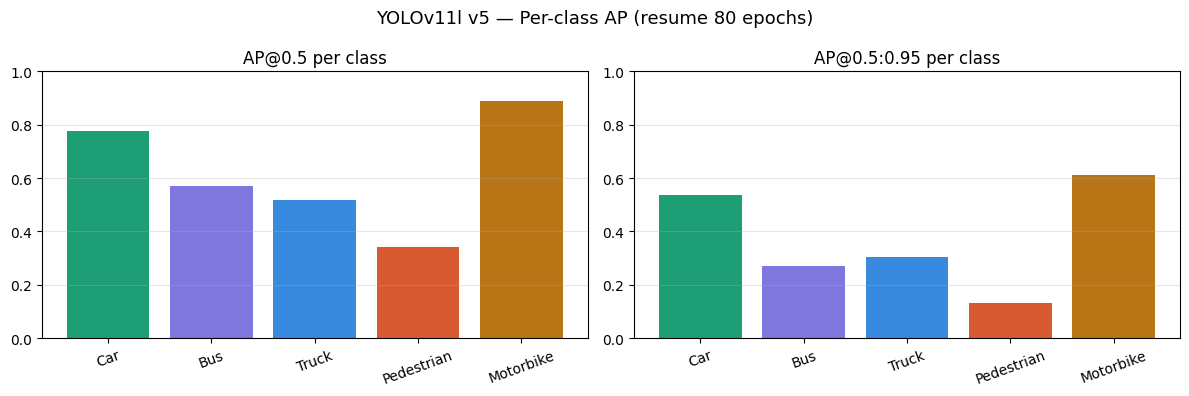


✅ CELL 5 HOÀN THÀNH — chạy Cell 6 (Lưu checkpoint)


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — VALIDATION + PER-CLASS AP                         ║
# ╚══════════════════════════════════════════════════════════════╝

best_ckpt_new = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
assert best_ckpt_new.exists(), f'Không tìm thấy best.pt: {best_ckpt_new}'

best_model = YOLO(str(best_ckpt_new))

val_results = best_model.val(
    data      = str(DATASET_YAML),
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    split     = 'val',
    verbose   = True,
    plots     = True,
    save_json = True,
)

print('\n=== Per-class AP (v5) ===')
rows_val = []
for i, name in enumerate(CLASS_NAMES):
    try:
        ap50   = float(val_results.box.ap50[i])
        ap5095 = float(val_results.box.ap[i])
        print(f'  {name:12s}  AP50={ap50:.3f}  AP50:95={ap5095:.3f}')
        rows_val.append({'class': name, 'AP50': ap50, 'AP50:95': ap5095})
    except Exception:
        pass

print(f'\nmAP@0.5      : {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {val_results.box.map:.4f}')

df_val = pd.DataFrame(rows_val)
if not df_val.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(df_val['class'], df_val['AP50'],    color=COLORS[:len(df_val)])
    axes[0].set_ylim(0, 1)
    axes[0].set_title('AP@0.5 per class')
    axes[0].tick_params(axis='x', rotation=20)
    axes[1].bar(df_val['class'], df_val['AP50:95'], color=COLORS[:len(df_val)])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('AP@0.5:0.95 per class')
    axes[1].tick_params(axis='x', rotation=20)
    for ax in axes:
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('YOLOv11l v5 — Per-class AP (resume 80 epochs)', fontsize=13)
    plt.tight_layout()
    plt.savefig(RUNS_DIR / RUN_NAME / 'perclass_ap_v5.png', dpi=150)
    plt.show()

df_val.to_csv(WORKING / 'perclass_ap_v5.csv', index=False)
print('\n✅ CELL 5 HOÀN THÀNH — chạy Cell 6 (Lưu checkpoint)')

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — LƯU CHECKPOINT MỚI                                ║
# ╚══════════════════════════════════════════════════════════════╝

best_src = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
last_src = RUNS_DIR / RUN_NAME / 'weights' / 'last.pt'

best_dst = CKPT_DIR / 'yolo11_fisheye_v5_best.pt'
last_dst = CKPT_DIR / 'yolo11_fisheye_v5_last.pt'

shutil.copy2(best_src, best_dst)
shutil.copy2(last_src, last_dst)

print(f'best.pt → {best_dst}  ({best_dst.stat().st_size/1e6:.1f} MB)')
print(f'last.pt → {last_dst}  ({last_dst.stat().st_size/1e6:.1f} MB)')

print('\n' + '='*55)
print('RESUME TRAINING HOÀN TẤT (80 epochs thêm)')
print('='*55)
for f in sorted(CKPT_DIR.glob('*')):
    print(f'  {f.name:45s} {f.stat().st_size/1e6:.1f} MB')

print('\n→ Bấm Save Version để lưu output vào Kaggle Dataset')
print('✅ PIPELINE v5 HOÀN TẤT')

best.pt → /kaggle/working/checkpoints/yolo11_fisheye_v5_best.pt  (51.2 MB)
last.pt → /kaggle/working/checkpoints/yolo11_fisheye_v5_last.pt  (51.2 MB)

RESUME TRAINING HOÀN TẤT (80 epochs thêm)
  yolo11_fisheye_v5_best.pt                     51.2 MB
  yolo11_fisheye_v5_last.pt                     51.2 MB

→ Bấm Save Version để lưu output vào Kaggle Dataset
✅ PIPELINE v5 HOÀN TẤT
